In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
%matplotlib inline
sns.set_style(style='whitegrid')
sns.set_context(context='notebook')
plt.rcParams['figure.figsize'] = (11, 9.4)

penguin_color = {
    'Adelie': '#ff6602ff',
    'Gentoo': '#0f7175ff',
    'Chinstrap': '#c65dc9ff'
}

In [3]:
titanic_df = sns.load_dataset('titanic')
titanic_df

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


# I. ANÁLISIS EXPLORATORIO DE DATOS

## I.01. TIPO DE DATOS:

In [4]:
titanic_df.dtypes

,0
survived,int64
pclass,int64
sex,object
age,float64
sibsp,int64
parch,int64
fare,float64
embarked,object
class,category
who,object


## I.02. CANTIDAD DE VARIABLES POR TIPO DATOS:

In [5]:
titanic_df.dtypes.value_counts()

,count
object,5
int64,4
float64,2
bool,2
category,1
category,1


## I.03. NÚMERO DE VARIABLES Y OBSERVACIONES:

In [6]:
titanic_df.shape

(891, 15)

## I.04. VALIDACIÓN DE NULOS EXPLICITOS:

In [7]:
titanic_df.isnull()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
887,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
888,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False
889,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [8]:
titanic_df.isnull().any()

,0
survived,False
pclass,False
sex,False
age,True
sibsp,False
parch,False
fare,False
embarked,True
class,False
who,False


## I.05. CANTIDAD DE VALORES NULOS:

In [9]:
titanic_df.isnull().sum().sort_values(ascending=False)

,0
deck,688
age,177
embarked,2
embark_town,2
survived,0
pclass,0
sex,0
sibsp,0
parch,0
fare,0


## I.06. TOTAL DE VALORES NULOS:

In [10]:
titanic_df.isnull().sum().sum()

869

## I.07. PROPORCIÓN DE VALORES NULOS POR VARIABLE:

In [11]:
plot_null_titanic = titanic_df.isnull().melt(value_name='missing')
plot_null_titanic

,variable,missing
0,survived,False
1,survived,False
2,survived,False
3,survived,False
4,survived,False
...,...,...
13360,alone,False
13361,alone,False
13362,alone,False
13363,alone,False


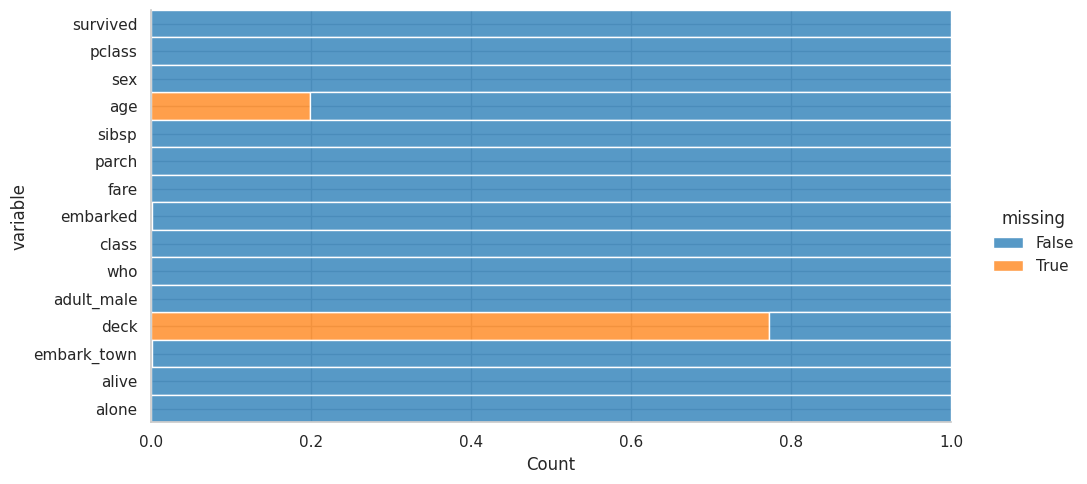

In [12]:
sns.displot(data=plot_null_titanic, y='variable', hue='missing', aspect=2, multiple='fill')

## I.08. VISUALIZACIÓN DE LOS VALORES NULOS EN EL CONJUNTO DE DATOS:

<Axes: >

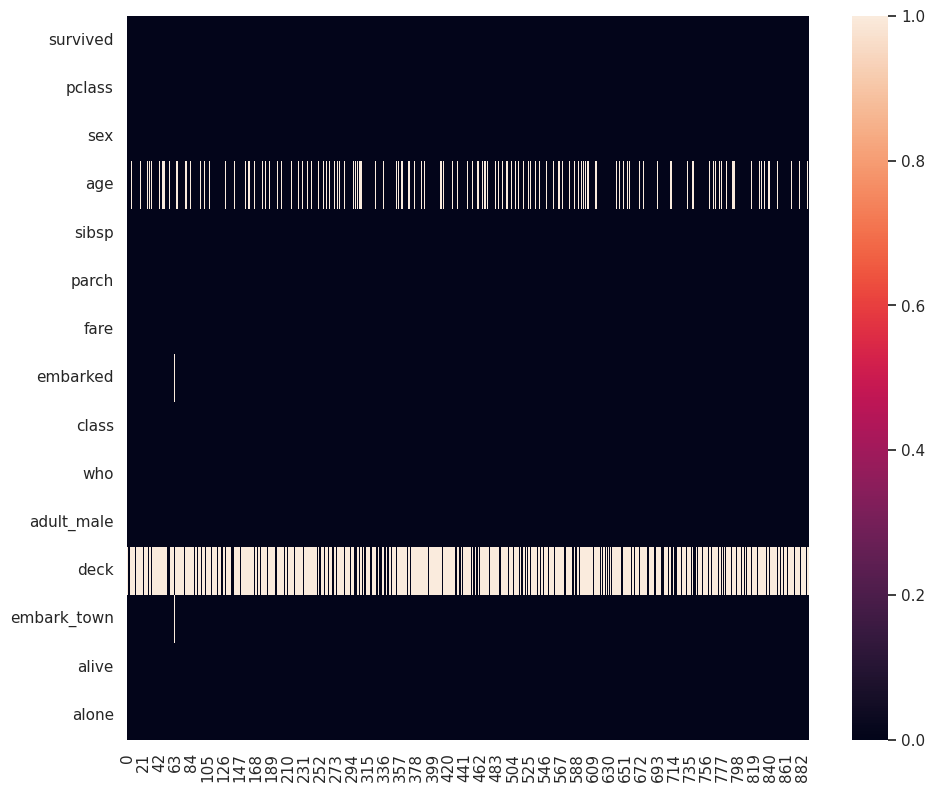

In [13]:
(
    titanic_df
    .isnull()
    .transpose()
    .pipe(
        lambda df: sns.heatmap(data=df)
    )
)

## I.09. CANTIDAD DE VALORES ELIMINADOS (NULOS):

In [14]:
processed_titanic_df = (
    titanic_df
    .dropna()
)
processed_titanic_df.shape

(182, 15)

In [15]:
titanic_df.shape[0] - processed_titanic_df.shape[0]

709

# II. CONTEOS

# II.01. CONTEO DE TODAS LAS VARIABLES

In [16]:
titanic_df.describe(include='all')

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
count,891.000000,891.000000,891,714.000000,891.000000,891.000000,891.000000,889,891,891,891,203,889,891,891
unique,NaN,NaN,2,NaN,NaN,NaN,NaN,3,3,3,2,7,3,2,2
top,NaN,NaN,male,NaN,NaN,NaN,NaN,S,Third,man,True,C,Southampton,no,True
freq,NaN,NaN,577,NaN,NaN,NaN,NaN,644,491,537,537,59,644,549,537
mean,0.383838,2.308642,NaN,29.699118,0.523008,0.381594,32.204208,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,0.486592,0.836071,NaN,14.526497,1.102743,0.806057,49.693429,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,0.000000,1.000000,NaN,0.420000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,0.000000,2.000000,NaN,20.125000,0.000000,0.000000,7.910400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,0.000000,3.000000,NaN,28.000000,0.000000,0.000000,14.454200,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,1.000000,3.000000,NaN,38.000000,1.000000,0.000000,31.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## II.02. CONTEO DE VARIABLES NUMERICAS

In [17]:
titanic_df.describe(include=[np.number])

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


## II.03. CONTEO DE VARIABLES CATEGORICAS

In [18]:
titanic_df.describe(include=object)

,sex,embarked,who,embark_town,alive
count,891,889,891,889,891
unique,2,3,3,3,2
top,male,S,man,Southampton,no
freq,577,644,537,644,549


In [19]:
(
    titanic_df
    .astype(
        {
            'sex' : 'category',
            'embarked' : 'category',
            'class' : 'category',
            'who' : 'category',
            'adult_male' : 'category',
            'deck' : 'category',
            'embark_town' : 'category',
            'alive' : 'category',
            'alone' : 'category'
        }
    )
).describe(include=['category', object])

,sex,embarked,class,who,adult_male,deck,embark_town,alive,alone
count,891,889,891,891,891,203,889,891,891
unique,2,3,3,3,2,7,3,2,2
top,male,S,Third,man,True,C,Southampton,no,True
freq,577,644,491,537,537,59,644,549,537


## II.03. GRAFICOS DE CONTEO

<Axes: xlabel='embark_town'>

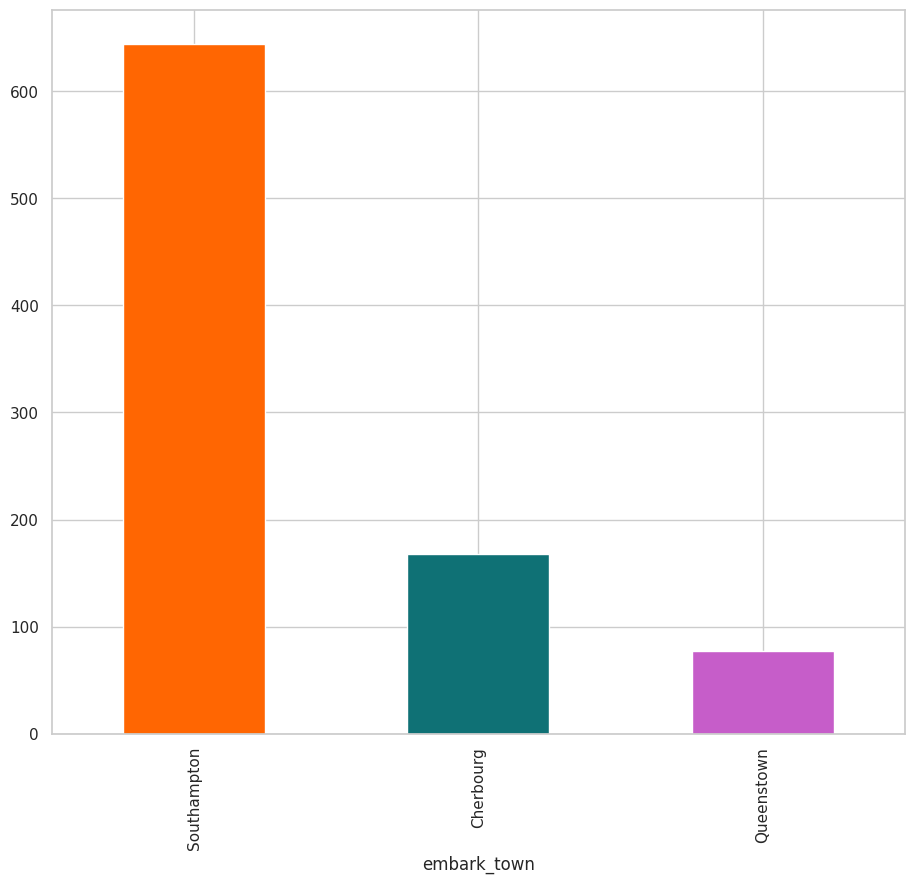

In [20]:
(
    titanic_df
    .embark_town
    .value_counts()
    .plot(
        kind='bar',
        color=penguin_color.values()
    )
)

In [21]:
embark_color = {
    'Southampton': '#ff6602ff',
    'Cherbourg': '#0f7175ff',
    'Queenstown': '#c65dc9ff'
}

<ipython-input-22-fce01c2003f3>:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


<Axes: xlabel='embark_town', ylabel='count'>

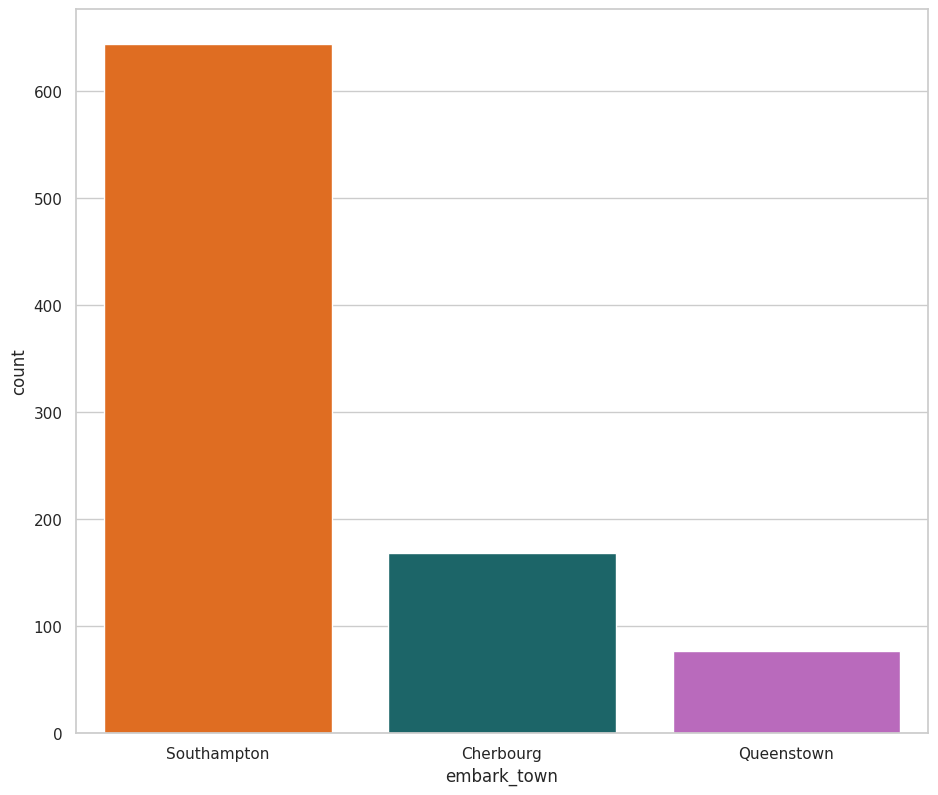

In [22]:
(
    titanic_df
    .value_counts('embark_town', sort=True)
    .reset_index(name='count')
    .pipe(
        lambda df: (
            sns.barplot(
                data=df,
                x='embark_town',
                y='count',
                palette=embark_color
            )
            )
        )
    )

# III. PROPORCIONES

In [23]:
titanic_df['variable'] = ''
titanic_df

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,variable
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False,
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False,
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True,
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False,
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True,
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True,
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True,
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False,
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True,


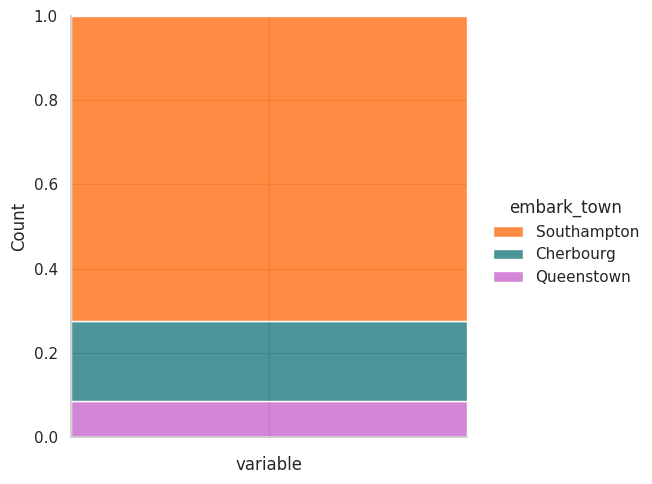

In [24]:
(
    titanic_df
    .pipe(
        lambda df: (
            sns.displot(
                data=df,
                x='variable',
                hue='embark_town',
                multiple='fill',
                palette=embark_color
            )
        )
    )
)

# IV. MEDIDAS DE TENDENCIA CENTRAL

## IV.01. MEDIA:

In [27]:
processed_titanic_df.age.mean()

35.62318681318681

In [29]:
processed_titanic_df.mean(numeric_only=True)

,0
survived,0.675824
pclass,1.192308
age,35.623187
sibsp,0.467033
parch,0.478022
fare,78.919735
adult_male,0.478022
alone,0.428571


## IV.02. MEDIANA:

In [31]:
processed_titanic_df.age.median()

36.0

## IV.03. MODA:

In [33]:
processed_titanic_df.age.mode().values[0]

36.0

## IV.04. GRÁFICA DE VALORES DE TENDENCIA CENTRAL

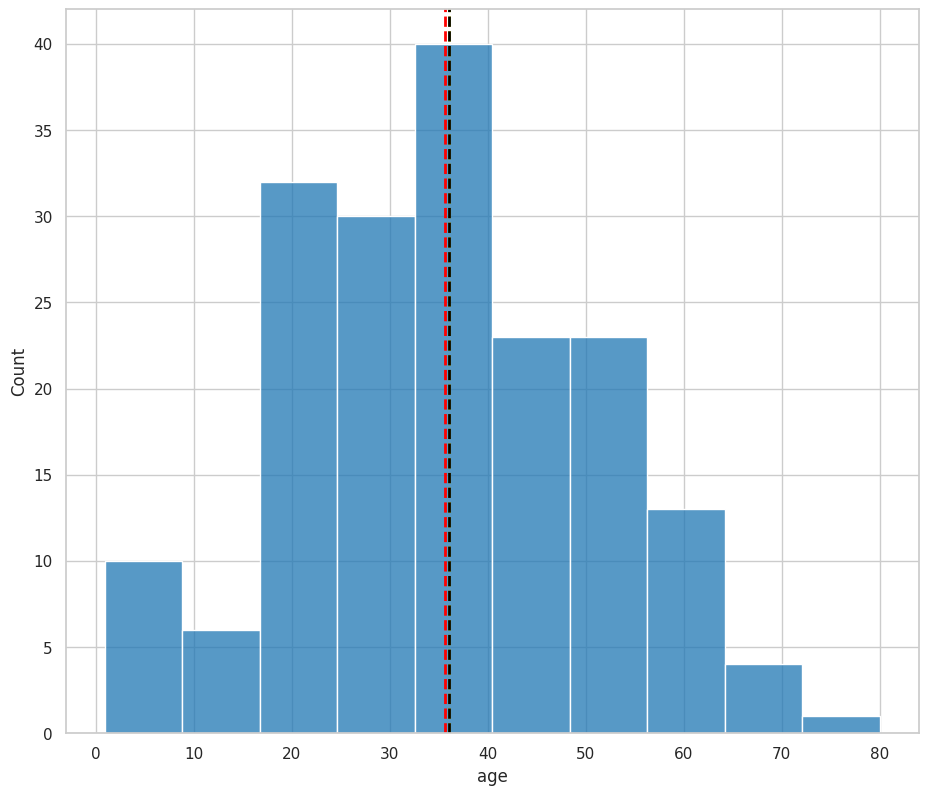

In [35]:
sns.histplot(
    data=processed_titanic_df,
    x='age'
)
plt.axvline(
    x=processed_titanic_df.age.mean(),
    color='red',
    linestyle='dashed',
    linewidth = 2
)
plt.axvline(
    x=processed_titanic_df.age.median(),
    color='yellow',
    linestyle='dashed',
    linewidth = 2
)
plt.axvline(
    x=processed_titanic_df.age.mode().values[0],
    color='black',
    linestyle='dashed',
    linewidth = 2
)

# V. MEDIDAS DE DISPERSIÓN

## V.01. RANGOS:

In [37]:
processed_titanic_df.min(numeric_only=True)

,0
survived,0
pclass,1
age,0.92
sibsp,0
parch,0
fare,0.0
adult_male,False
alone,False


In [38]:
processed_titanic_df.max(numeric_only=True)

,0
survived,1
pclass,3
age,80.0
sibsp,3
parch,4
fare,512.3292
adult_male,True
alone,True


In [43]:
rango = processed_titanic_df.select_dtypes(include='number').max() - processed_titanic_df.select_dtypes(include='number').min()
rango

,0
survived,1.0000
pclass,2.0000
age,79.0800
sibsp,3.0000
parch,4.0000
fare,512.3292


## V.02. DESVIACIÓN STANDARD:

In [44]:
processed_titanic_df.std(numeric_only=True)

,0
survived,0.469357
pclass,0.516411
age,15.671615
sibsp,0.645007
parch,0.755869
fare,76.490774
adult_male,0.500895
alone,0.496237


In [45]:
processed_titanic_df.mean(numeric_only=True) + processed_titanic_df.std(numeric_only=True)

,0
survived,1.145181
pclass,1.708719
age,51.294802
sibsp,1.112040
parch,1.233891
fare,155.410509
adult_male,0.978917
alone,0.924808


## V.03. RANGO INTERCUARTILICO

### V.03.1. Q1 - 25%:

In [48]:
processed_titanic_df.select_dtypes(include='number').quantile(0.25, numeric_only=True)

,0.25
survived,0.0
pclass,1.0
age,24.0
sibsp,0.0
parch,0.0
fare,29.7


In [49]:
processed_titanic_df.select_dtypes(include='number').quantile(0.75, numeric_only=True) - processed_titanic_df.select_dtypes(include='number').quantile(0.25, numeric_only=True)

,0
survived,1.00
pclass,0.00
age,23.75
sibsp,1.00
parch,1.00
fare,60.30


### V.03.2. TODOS LOS QUARTILES:

In [50]:
(
    processed_titanic_df
    .select_dtypes(include='number')
    .quantile([0.75, 0.5, 0.25], numeric_only=True)
    .transpose()
    .rename_axis('metric')
    .reset_index()
    .assign(
        iqr = lambda df: df[0.75] - df[0.25]
    )
)

,metric,0.75,0.5,0.25,iqr
0,survived,1.00,1.0,0.0,1.00
1,pclass,1.00,1.0,1.0,0.00
2,age,47.75,36.0,24.0,23.75
3,sibsp,1.00,0.0,0.0,1.00
4,parch,1.00,0.0,0.0,1.00
5,fare,90.00,57.0,29.7,60.30


## V.04. GRAFICAS DE TODAS LAS MEDIDAS

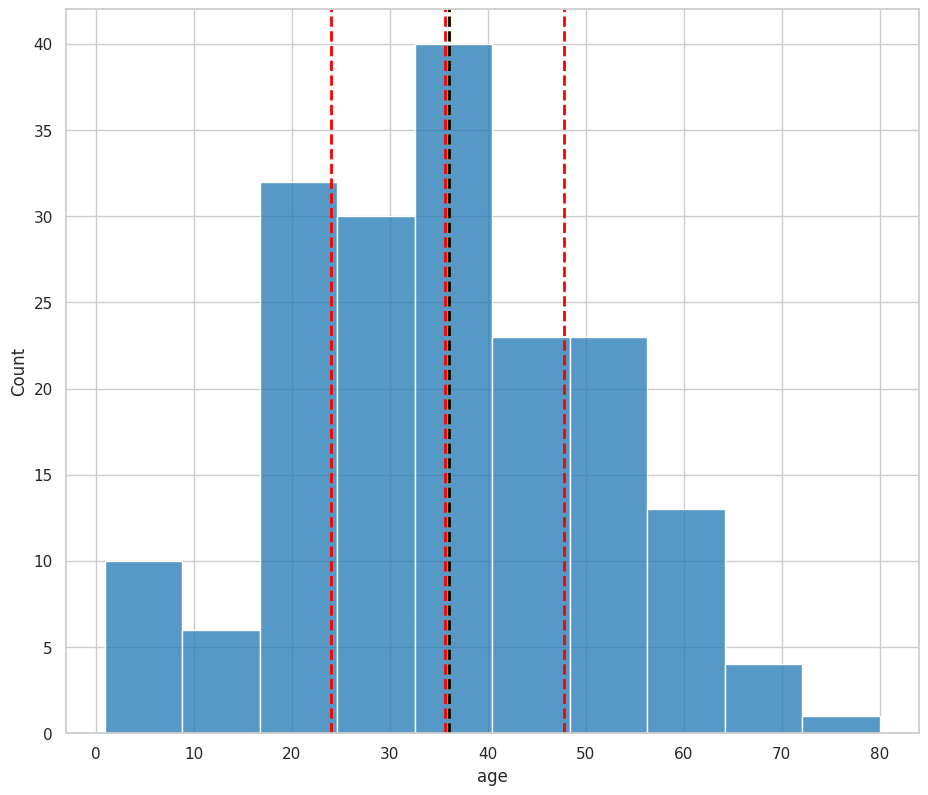

In [51]:
sns.histplot(
    data=processed_titanic_df,
    x='age'
)
plt.axvline(
    x=processed_titanic_df.age.mean(),
    color='red',
    linestyle='dashed',
    linewidth = 2
)
plt.axvline(
    x=processed_titanic_df.age.median(),
    color='yellow',
    linestyle='dashed',
    linewidth = 2
)
plt.axvline(
    x=processed_titanic_df.age.mode().values[0],
    color='black',
    linestyle='dashed',
    linewidth = 2
)
plt.axvline(
    x=processed_titanic_df.age.quantile(0.25),
    color='red',
    linestyle='dashed',
    linewidth = 2
)
plt.axvline(
    x=processed_titanic_df.age.quantile(0.75),
    color='red',
    linestyle='dashed',
    linewidth = 2
)

# VI. DISTRIBUCIONES

## VI.01. EMPIRICALDIST

In [52]:
!pip install empiricaldist

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for empiricaldist: filename=empiricaldist-0.8.0-py3-none-any.whl size=12556 sha256=f587c303f01bac265248a988dd38e8c6116dfb68b5df8d8c646de46844cb590b
  Stored in directory: /root/.cache/pip/wheels/ca/a9/1f/90c7a8a37ac37ff0fa0a27b2152f9b24be8910448ab93992f8
Successfully built empiricaldist


In [53]:
import empiricaldist

## VI.02. FUNCIÓN DE PROBABILIDAD DE MASAS (PMFs):

In [54]:
empiricaldist.Pmf.from_seq(
    processed_titanic_df.age,
    normalize=True
)

,
age,
0.92,0.005495
1.00,0.005495
2.00,0.016484
3.00,0.005495
4.00,0.016484
...,...
64.00,0.005495
65.00,0.010989
70.00,0.005495


In [55]:
pmf_age = empiricaldist.Pmf.from_seq(
    processed_titanic_df.age,
    normalize=True
)

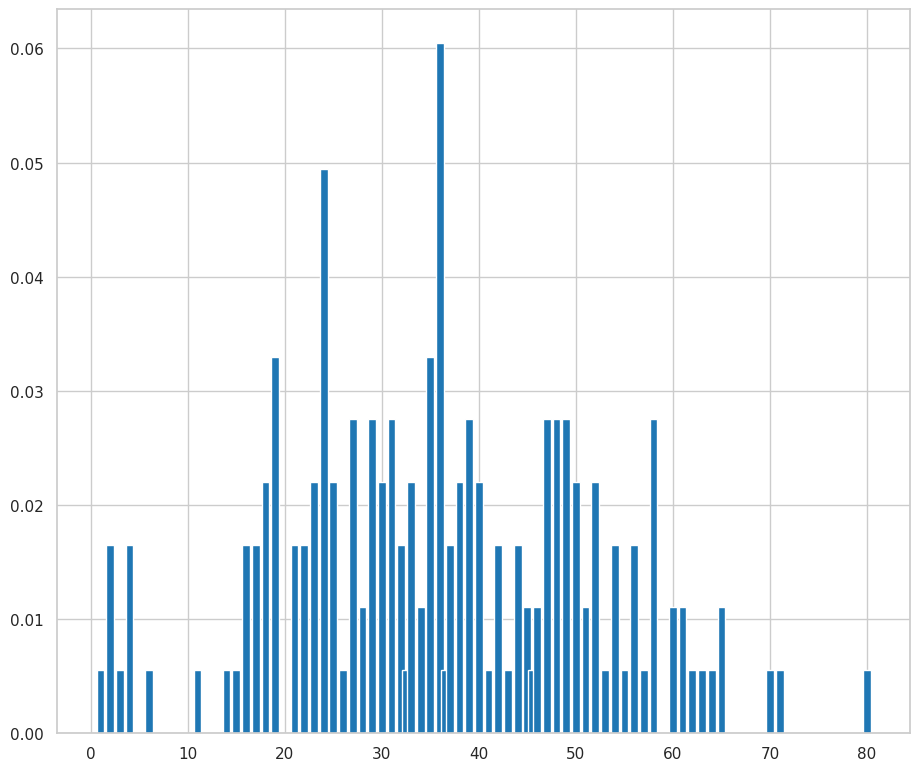

In [56]:
pmf_age.bar()

In [57]:
pmf_age(32)

0.016483516483516484

## VI.03. FUNCIÓN DE DISTRIBUCIÓN ACUMULADA:

In [58]:
cdf_age = empiricaldist.Cdf.from_seq(
    processed_titanic_df.age,
    normalize=True
)
cdf_age

,
age,
0.92,0.005495
1.00,0.010989
2.00,0.027473
3.00,0.032967
4.00,0.049451
...,...
64.00,0.972527
65.00,0.983516
70.00,0.989011


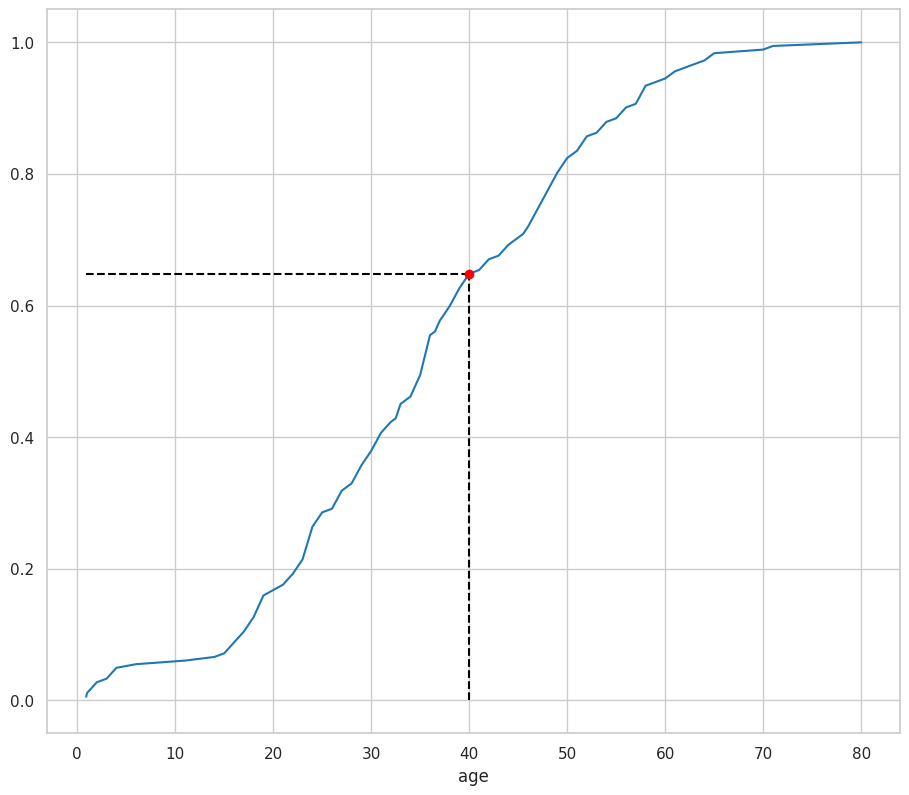

In [61]:
cdf_age.plot()
q = 40
p = cdf_age.forward(q)

plt.vlines(
    x=q,
    ymin=0,
    ymax=p,
    color='black',
    linestyle='dashed'
)

plt.hlines(
    y=p,
    xmin=pmf_age.qs[0],
    xmax=q,
    color='black',
    linestyle='dashed'
)

plt.plot(q, p, 'ro')

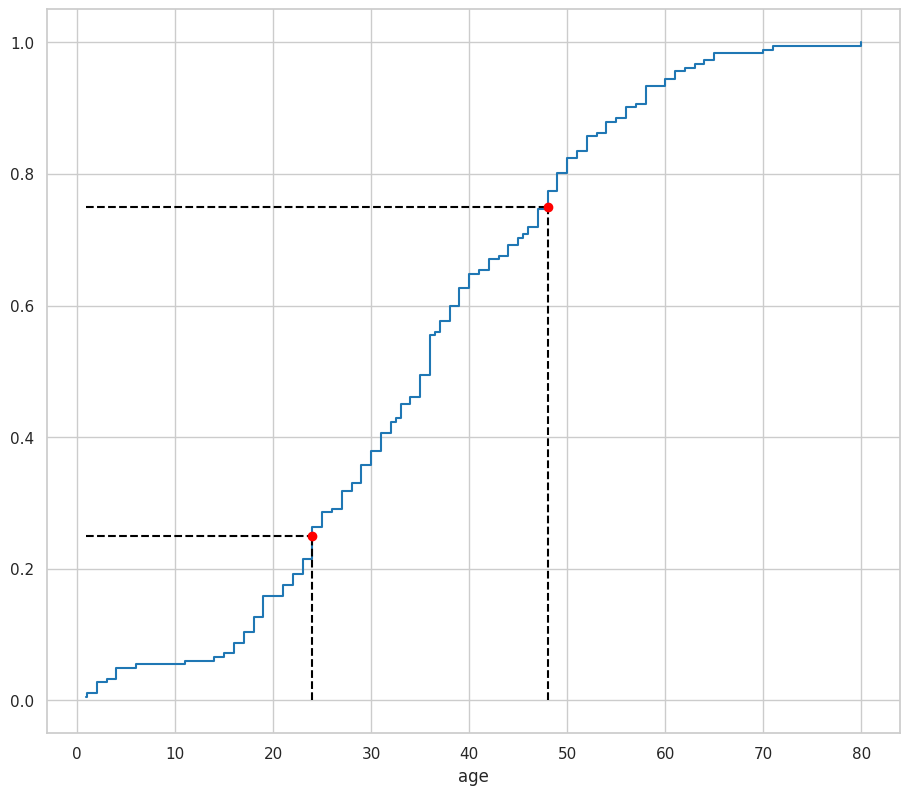

In [62]:
cdf_age.step()

p_1 = 0.25
p_2 = 0.75

ps = (0.25, 0.75)
qs = cdf_age.inverse(ps)

plt.vlines(
    x=qs,
    ymin=0,
    ymax=ps,
    color='black',
    linestyle='dashed'
)

plt.hlines(
    y=ps,
    xmin=pmf_age.qs[0],
    xmax=qs,
    color='black',
    linestyle='dashed'
)

plt.scatter(
    x=qs,
    y=ps,
    color='red',
    zorder=2
)

## VI.04. COMPARANDO DISTRIBUCIONES:

<Axes: xlabel='age', ylabel='Proportion'>

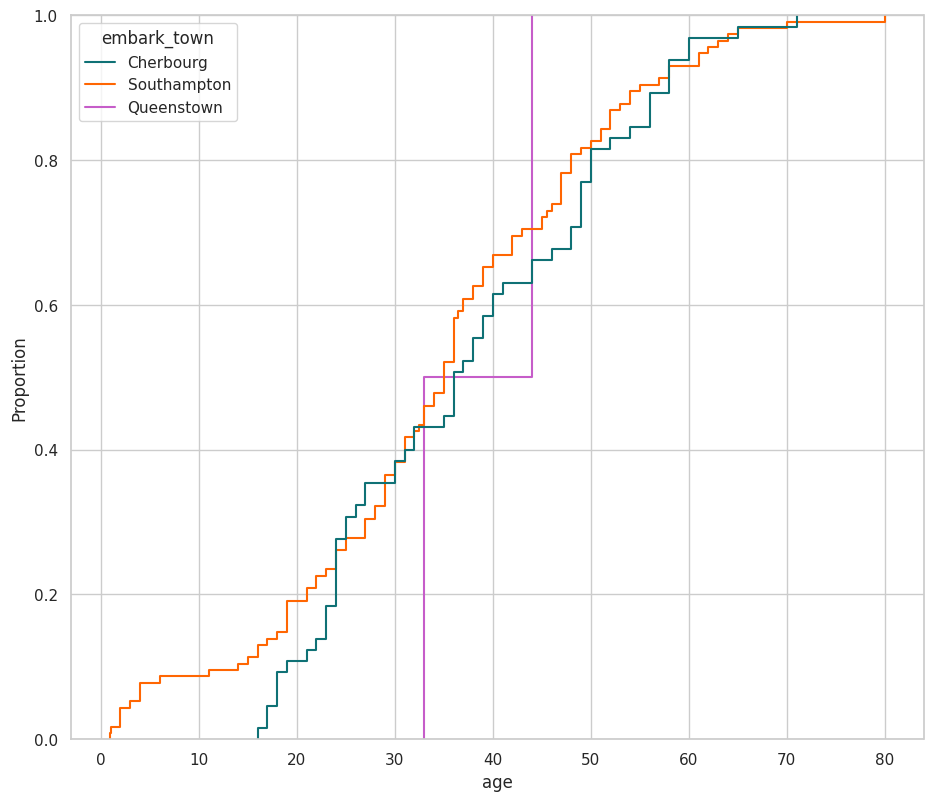

In [63]:
sns.ecdfplot(
    data=processed_titanic_df,
    x='age',
    hue='embark_town',
    palette=embark_color
)

## VI.05. FUNCIONES DE DENSIDAD DE PROBABILIDAD:

<Axes: xlabel='age', ylabel='Density'>

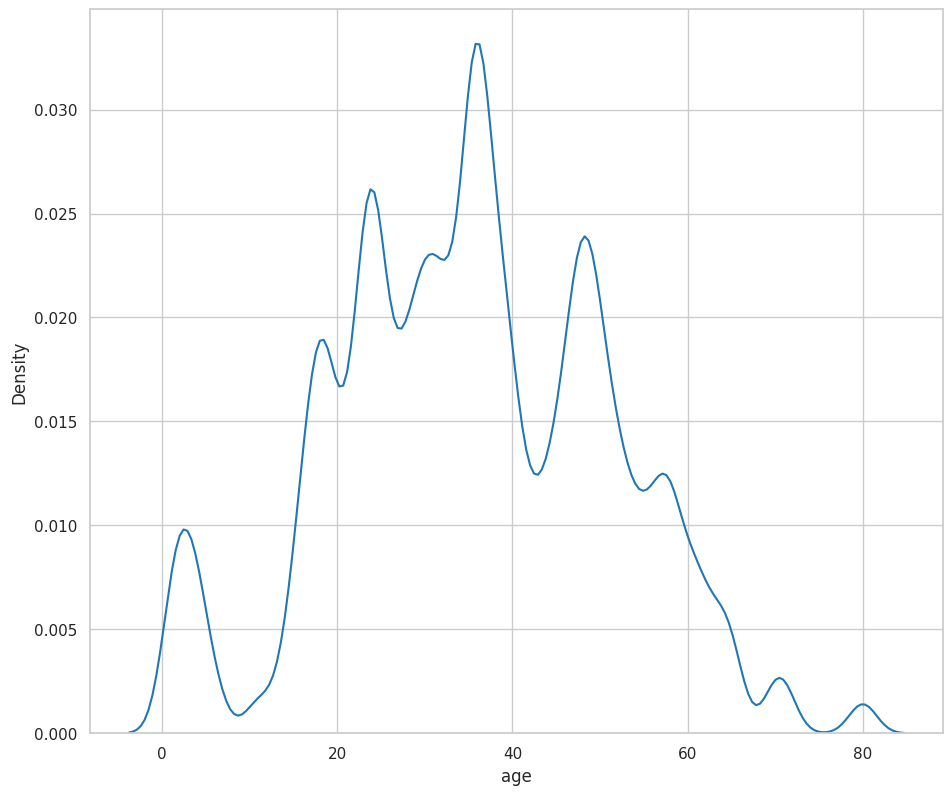

In [64]:
sns.kdeplot(
    data=processed_titanic_df,
    x='age',
    bw_method=0.1
)

In [65]:
stats = processed_titanic_df.age.describe()
stats

,age
count,182.000000
mean,35.623187
std,15.671615
min,0.920000
25%,24.000000
50%,36.000000
75%,47.750000
max,80.000000


## VI.06. GENERACIÓN DE UN VECTOR:

In [66]:
!pip install scipy

In [67]:
import scipy

In [68]:
xs = np.linspace(stats['min'], stats['max'])
ys = scipy.stats.norm(stats['mean'], stats['std']).cdf(xs)
ys

array([0.01340072, 0.01736826, 0.02229851, 0.02836049, 0.03573544,
       0.04461318, 0.05518727, 0.06764912, 0.08218095, 0.09894799,
       0.11809014, 0.13971353, 0.16388231, 0.19061141, 0.21986048,
       0.25152976, 0.28545811, 0.32142357, 0.35914661, 0.39829612,
       0.4384978 , 0.47934483, 0.52041013, 0.56125974, 0.6014665 ,
       0.64062344, 0.67835604, 0.71433288, 0.74827412, 0.77995743,
       0.80922132, 0.83596564, 0.86014972, 0.88178816, 0.90094486,
       0.9177257 , 0.93227041, 0.94474409, 0.9553289 , 0.96421619,
       0.97159954, 0.97766882, 0.98260531, 0.98657813, 0.98974169,
       0.99223429, 0.99417753, 0.99567653, 0.99682065, 0.99768471])

<Axes: xlabel='age'>

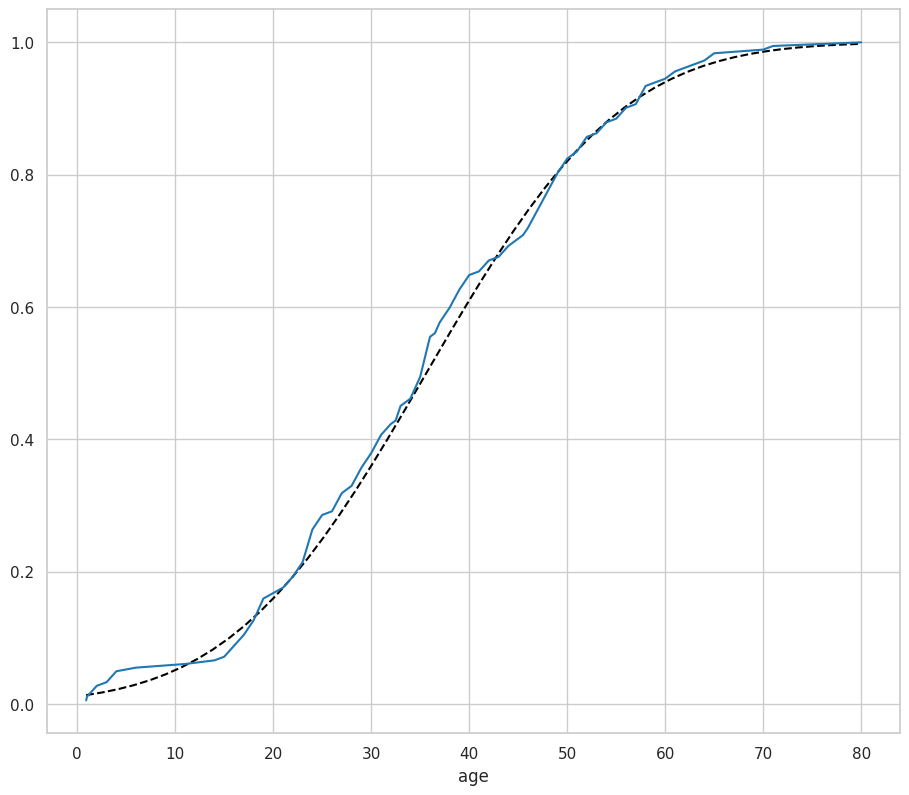

In [69]:
plt.plot(xs, ys, color='black', linestyle='dashed')
empiricaldist.Cdf.from_seq(
    processed_titanic_df.age,
    normalize=True
).plot()

<Axes: xlabel='age', ylabel='Density'>

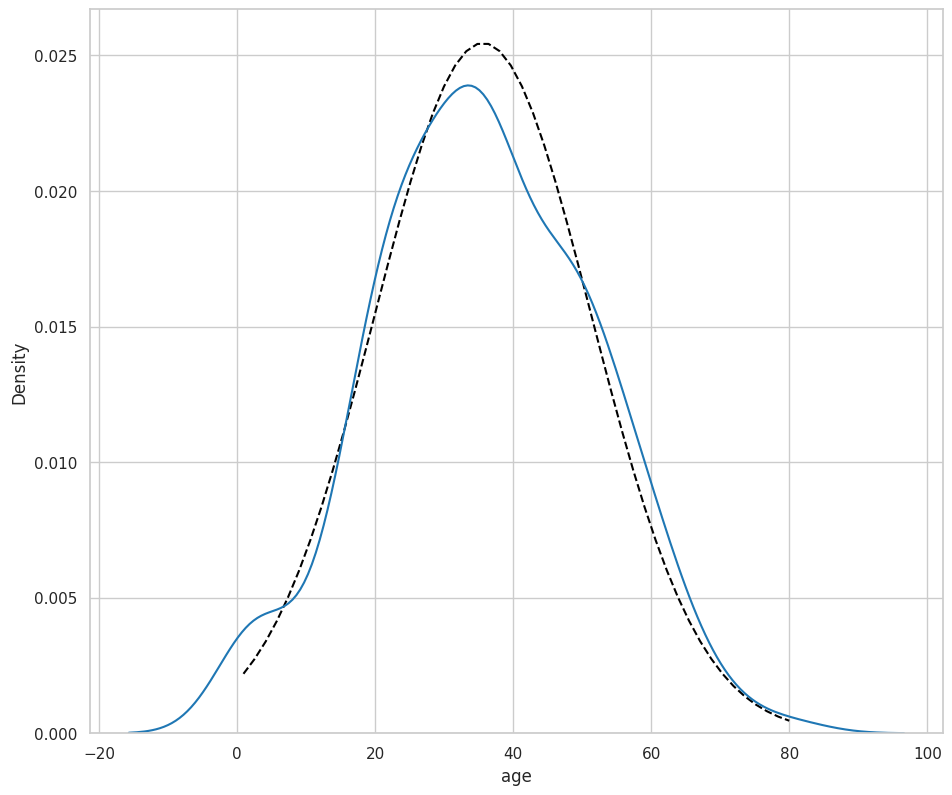

In [71]:
xs = np.linspace(stats['min'], stats['max'])
ys = scipy.stats.norm(stats['mean'], stats['std']).pdf(xs)
plt.plot(xs, ys, color='black', linestyle='dashed')

sns.kdeplot(
    data=processed_titanic_df,
    x='age'
)